In [1]:
from google.colab import files

uploaded = files.upload()

Saving Untitled8_ipynb_py (1).ipynb to Untitled8_ipynb_py (1).ipynb


In [2]:
# 1. Libraries / Project Setup

import os
import zipfile
import urllib.request
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    IsolationForest
)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import StandardScaler

# Model saving
import joblib

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# 2. Download and Extract NASA C-MAPSS Dataset

import os
import zipfile
import urllib.request

DATA_URL = "https://data.nasa.gov/docs/legacy/CMAPSSData.zip"
ZIP_PATH = "/content/CMAPSSData.zip"
BASE_DIR = "/content/CMAPSSData"

print("Downloading NASA C-MAPSS dataset...")

# Download ZIP if it does not already exist
if not os.path.exists(ZIP_PATH):
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

print("Download completed!")

# Extract dataset
os.makedirs(BASE_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(BASE_DIR)

print("Dataset extracted successfully!")

# Find the folder containing train_FD001.txt
train_file = None

for root, dirs, files in os.walk(BASE_DIR):
    if "train_FD001.txt" in files:
        train_file = os.path.join(root, "train_FD001.txt")
        DATA_DIR = root
        break

if train_file:
    print("Dataset location found:")
    print(DATA_DIR)
    print("train_FD001.txt found successfully!")
else:
    print("ERROR: train_FD001.txt was not found.")

Download completed!
Dataset extracted successfully!
Dataset location found:
/content/CMAPSSData
train_FD001.txt found successfully!


In [4]:
# 3. Load NASA C-MAPSS FD001 Dataset

import os
import pandas as pd

# Automatically find the dataset files
train_file = None
test_file = None
rul_file = None

for root, dirs, files in os.walk("/content"):
    if "train_FD001.txt" in files:
        train_file = os.path.join(root, "train_FD001.txt")
    if "test_FD001.txt" in files:
        test_file = os.path.join(root, "test_FD001.txt")
    if "RUL_FD001.txt" in files:
        rul_file = os.path.join(root, "RUL_FD001.txt")

# Check files
print("Train file:", train_file)
print("Test file :", test_file)
print("RUL file  :", rul_file)

# Stop with a clear message if files are missing
if train_file is None or test_file is None or rul_file is None:
    raise FileNotFoundError(
        "NASA dataset files not found. Please run Cell 2 first."
    )

# Column names
cols = (
    ["unit", "cycle", "setting_1", "setting_2", "setting_3"] +
    [f"sensor_{i}" for i in range(1, 22)]
)

# Load data
train = pd.read_csv(
    train_file,
    sep=r"\s+",
    header=None,
    names=cols
)

test = pd.read_csv(
    test_file,
    sep=r"\s+",
    header=None,
    names=cols
)

true_rul = pd.read_csv(
    rul_file,
    header=None,
    names=["RUL"]
)

# Display results
print("\nDataset loaded successfully!")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Number of train engines:", train["unit"].nunique())
print("Number of test engines :", test["unit"].nunique())

print("\nFirst 5 training records:")
display(train.head())

Train file: /content/CMAPSSData/train_FD001.txt
Test file : /content/CMAPSSData/test_FD001.txt
RUL file  : /content/CMAPSSData/RUL_FD001.txt

Dataset loaded successfully!
Train shape: (20631, 26)
Test shape : (13096, 26)
Number of train engines: 100
Number of test engines : 100

First 5 training records:


,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
# 4. Basic data inspection
print("Missing values in train:", train.isna().sum().sum())
print("Duplicate rows in train:", train.duplicated().sum())

print("\nData types:")
print(train.dtypes.value_counts())

print("\nTrain summary:")
display(train.describe().T)


Missing values in train: 0
Duplicate rows in train: 0

Data types:
float64    22
int64       4
Name: count, dtype: int64

Train summary:


,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


In [6]:
# 5. Create RUL target
max_cycle = train.groupby("unit")["cycle"].transform("max")
train["RUL"] = max_cycle - train["cycle"]

RUL_CAP = 125
train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)

print(train[["unit", "cycle", "RUL", "RUL_capped"]].head(10))


   unit  cycle  RUL  RUL_capped
0     1      1  191         125
1     1      2  190         125
2     1      3  189         125
3     1      4  188         125
4     1      5  187         125
5     1      6  186         125
6     1      7  185         125
7     1      8  184         125
8     1      9  183         125
9     1     10  182         125


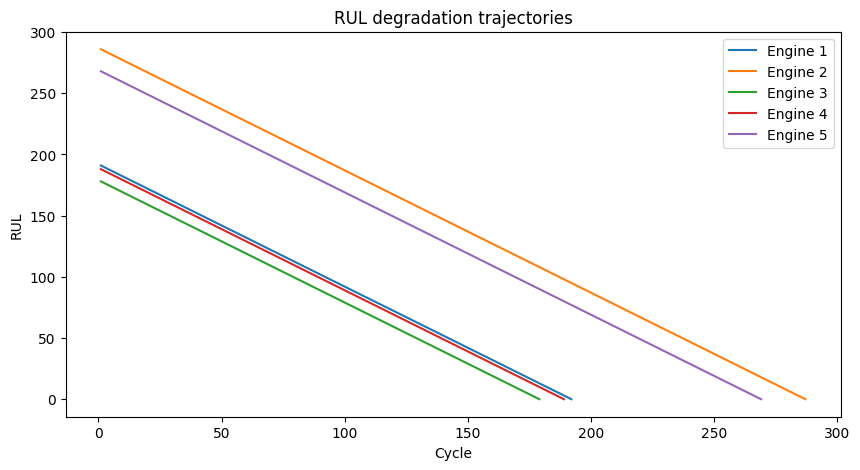

In [7]:
# 6. Plot RUL trajectory for a few engines
plt.figure(figsize=(10, 5))
for unit in [1, 2, 3, 4, 5]:
    d = train[train["unit"] == unit]
    plt.plot(d["cycle"], d["RUL"], label=f"Engine {unit}")
plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title("RUL degradation trajectories")
plt.legend()
plt.show()


In [8]:
# Sensor variance analysis
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
sensor_std = train[sensor_cols].std().sort_values()

display(sensor_std.to_frame("std").head(10))

constant_sensors = sensor_std[sensor_std == 0].index.tolist()
print("Constant sensors:", constant_sensors)


,std
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.556432e-14
sensor_10,4.660829e-13
sensor_5,3.394700e-12
sensor_1,6.537152e-11
sensor_6,1.388985e-03
sensor_15,3.750504e-02
sensor_8,7.098548e-02
sensor_13,7.191892e-02


Constant sensors: ['sensor_19', 'sensor_18']


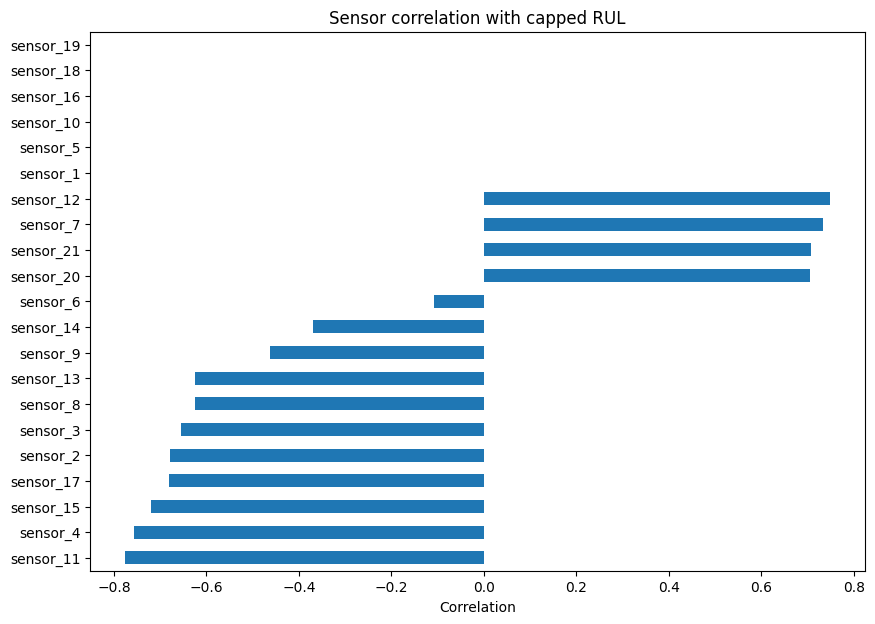

Most negatively correlated sensors:


,correlation
sensor_11,-0.775230
sensor_4,-0.757157
sensor_15,-0.720858
sensor_17,-0.680829
sensor_2,-0.678458
sensor_3,-0.655030
sensor_8,-0.624568
sensor_13,-0.624034


In [9]:
# Correlation of sensors with RUL
corr = train[sensor_cols + ["RUL_capped"]].corr()["RUL_capped"].drop("RUL_capped").sort_values()

plt.figure(figsize=(10, 7))
corr.plot(kind="barh")
plt.title("Sensor correlation with capped RUL")
plt.xlabel("Correlation")
plt.show()

print("Most negatively correlated sensors:")
display(corr.head(8).to_frame("correlation"))


In [10]:
import pandas as pd

file_path = "/content/CMAPSSData/train_FD001.txt"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (20631, 26)
   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
1  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00   
2  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0  38.95   
3  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0  38.88   
4  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0  38.90   

        25  
0  23.4190  
1  23.4236  

In [11]:
# 7. Feature Engineering

# Give names to all columns
columns = (
    ["unit", "cycle", "setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df.columns = columns

# Sensor columns
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

# Find constant sensors
constant_sensors = [
    c for c in sensor_cols
    if df[c].nunique() <= 1
]

# Remove constant sensors
drop_sensors = constant_sensors

base_features = [
    "cycle", "setting_1", "setting_2", "setting_3"
] + [
    c for c in sensor_cols if c not in drop_sensors
]

print("Constant sensors:", constant_sensors)
print("Features used:", base_features)

Constant sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Features used: ['cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [12]:
# Create training dataframe

train_fe = df.copy()

print("train_fe created successfully!")
print("Shape:", train_fe.shape)
print(train_fe.head())

train_fe created successfully!
Shape: (20631, 26)
   unit  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  sensor_3  \
0     1      1    -0.0007    -0.0004      100.0    518.67    641.82   1589.70   
1     1      2     0.0019    -0.0003      100.0    518.67    642.15   1591.82   
2     1      3    -0.0043     0.0003      100.0    518.67    642.35   1587.99   
3     1      4     0.0007     0.0000      100.0    518.67    642.35   1582.79   
4     1      5    -0.0019    -0.0002      100.0    518.67    642.37   1582.85   

   sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  sensor_15  \
0   1400.60     14.62  ...     521.66    2388.02    8138.62     8.4195   
1   1403.14     14.62  ...     522.28    2388.07    8131.49     8.4318   
2   1404.20     14.62  ...     522.42    2388.03    8133.23     8.4178   
3   1401.87     14.62  ...     522.86    2388.08    8133.83     8.3682   
4   1406.22     14.62  ...     522.19    2388.04    8133.80     8.4294   

   sensor_16  sens

In [13]:
# Define feature columns

feature_cols = base_features

print("Feature columns:")
print(feature_cols)

Feature columns:
['cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [14]:
# Create RUL (Remaining Useful Life)

max_cycle = train_fe.groupby("unit")["cycle"].transform("max")
train_fe["RUL"] = max_cycle - train_fe["cycle"]

# Cap RUL at 125
train_fe["RUL_capped"] = train_fe["RUL"].clip(upper=125)

print("RUL columns created successfully!")
print(train_fe[["unit", "cycle", "RUL", "RUL_capped"]].head())

RUL columns created successfully!
   unit  cycle  RUL  RUL_capped
0     1      1  191         125
1     1      2  190         125
2     1      3  189         125
3     1      4  188         125
4     1      5  187         125


In [15]:
# 8. Group-based train/validation split
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, val_idx = next(gss.split(train_fe, groups=train_fe["unit"]))

tr = train_fe.iloc[train_idx].copy()
va = train_fe.iloc[val_idx].copy()

X_train = tr[feature_cols]
y_train = tr["RUL_capped"]

X_val = va[feature_cols]
y_val = va["RUL_capped"]

print("Training engines:", tr["unit"].nunique())
print("Validation engines:", va["unit"].nunique())
print("Training rows:", len(tr))
print("Validation rows:", len(va))


Training engines: 80
Validation engines: 20
Training rows: 16561
Validation rows: 4070


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

print("Libraries ready!")

Libraries ready!


In [30]:
# 9. Train Random Forest RUL Regressor

rul_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rul_model.fit(X_train, y_train)

val_pred = rul_model.predict(X_val)

mae = mean_absolute_error(y_val, val_pred)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
r2 = r2_score(y_val, val_pred)

print(f"Validation MAE : {mae:.2f} cycles")
print(f"Validation RMSE: {rmse:.2f} cycles")
print(f"Validation R²  : {r2:.3f}")

Validation MAE : 10.81 cycles
Validation RMSE: 15.93 cycles
Validation R²  : 0.854


In [31]:
import joblib

joblib.dump(rul_model, "model.pkl")

print("Model saved successfully!")

Model saved successfully!


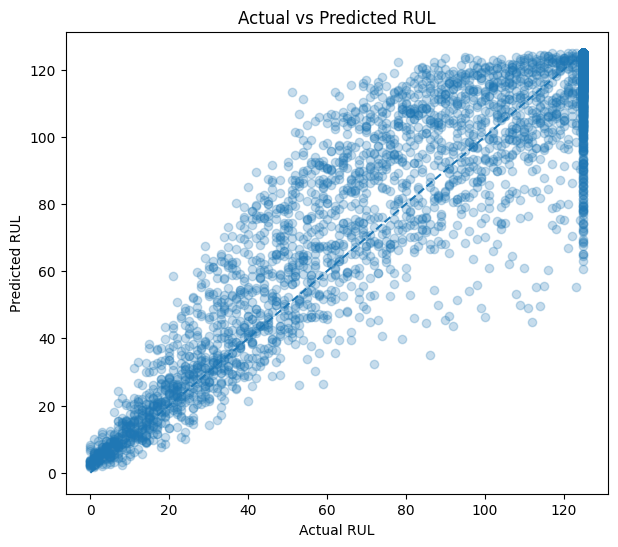

In [18]:
# 10. Actual vs predicted RUL
plt.figure(figsize=(7, 6))
plt.scatter(y_val, val_pred, alpha=0.25)
lims = [0, max(y_val.max(), val_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()


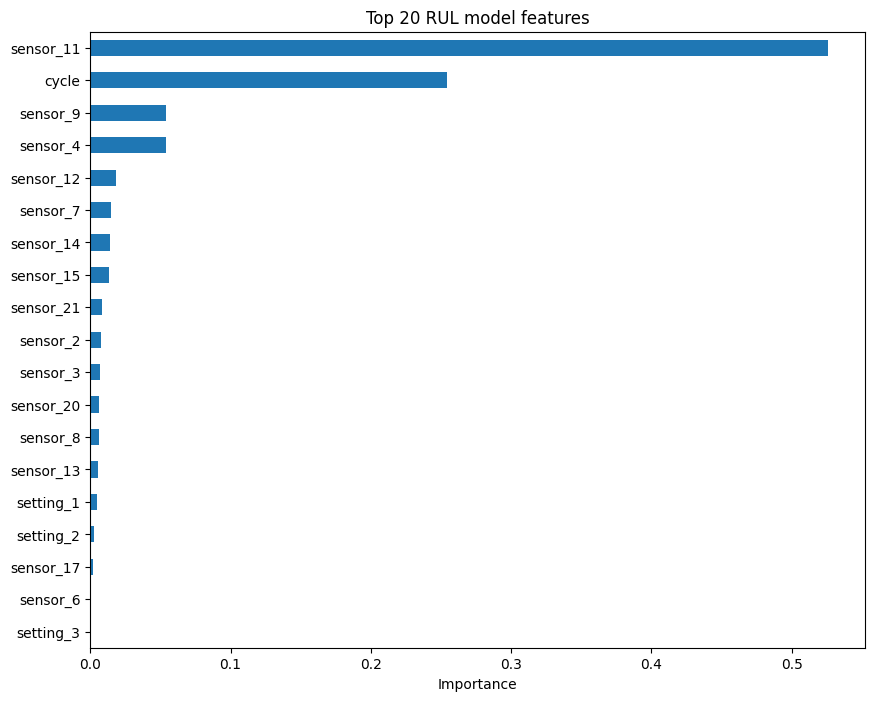

,importance
sensor_11,0.526159
cycle,0.254245
sensor_9,0.054267
sensor_4,0.053735
sensor_12,0.018402
sensor_7,0.014653
sensor_14,0.013949
sensor_15,0.013467
sensor_21,0.008287
sensor_2,0.007995


In [19]:
# Feature importance
importance = pd.Series(rul_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 RUL model features")
plt.xlabel("Importance")
plt.show()

display(importance.head(20).to_frame("importance"))


In [20]:
# 11. Failure-risk target
train_fe["failure_risk"] = (train_fe["RUL_capped"] <= 30).astype(int)

tr = train_fe.iloc[train_idx].copy()
va = train_fe.iloc[val_idx].copy()

clf = RandomForestClassifier(
    n_estimators=250,
    max_depth=16,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf.fit(tr[feature_cols], tr["failure_risk"])
risk_pred = clf.predict(va[feature_cols])

print("Accuracy :", round(accuracy_score(va["failure_risk"], risk_pred), 4))
print("Precision:", round(precision_score(va["failure_risk"], risk_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(va["failure_risk"], risk_pred, zero_division=0), 4))
print("F1-score :", round(f1_score(va["failure_risk"], risk_pred, zero_division=0), 4))
print("\nClassification report:")
print(classification_report(va["failure_risk"], risk_pred, zero_division=0))


Accuracy : 0.9627
Precision: 0.8622
Recall   : 0.8984
F1-score : 0.8799

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      3450
           1       0.86      0.90      0.88       620

    accuracy                           0.96      4070
   macro avg       0.92      0.94      0.93      4070
weighted avg       0.96      0.96      0.96      4070



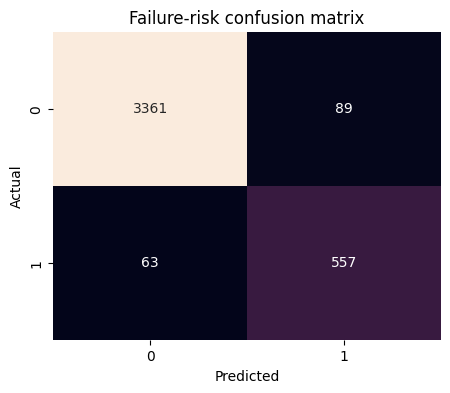

In [21]:
# Confusion matrix
cm = confusion_matrix(va["failure_risk"], risk_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Failure-risk confusion matrix")
plt.show()


In [22]:
# 12. Isolation Forest on selected sensor features
usable_sensors = [c for c in sensor_cols if c not in constant_sensors]

scaler = StandardScaler()
X_sensor = scaler.fit_transform(train_fe[usable_sensors])

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=RANDOM_STATE
)
train_fe["anomaly"] = (iso.fit_predict(X_sensor) == -1).astype(int)

print("Detected anomalies:", int(train_fe["anomaly"].sum()))
print("Anomaly rate:", round(train_fe["anomaly"].mean() * 100, 2), "%")


Detected anomalies: 413
Anomaly rate: 2.0 %


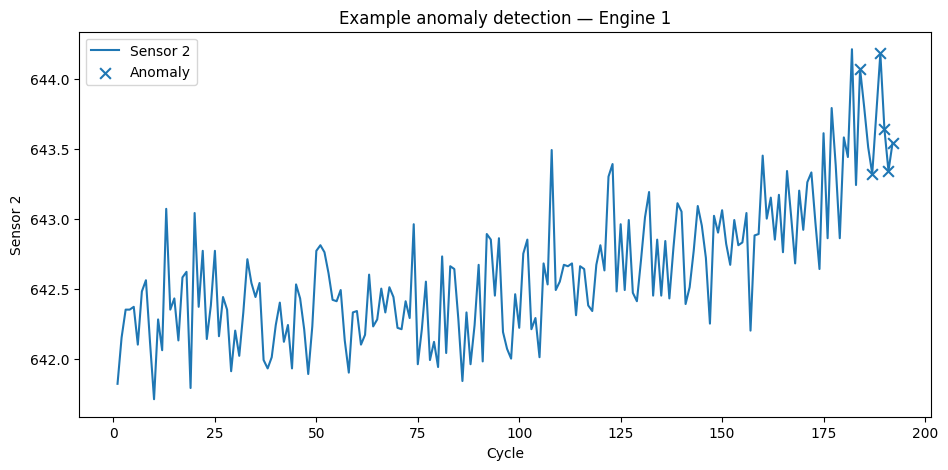

In [23]:
# Visualize anomalies for Engine 1
e1 = train_fe[train_fe["unit"] == 1]

plt.figure(figsize=(11, 5))
plt.plot(e1["cycle"], e1["sensor_2"], label="Sensor 2")
an = e1[e1["anomaly"] == 1]
plt.scatter(an["cycle"], an["sensor_2"], marker="x", s=60, label="Anomaly")
plt.xlabel("Cycle")
plt.ylabel("Sensor 2")
plt.title("Example anomaly detection — Engine 1")
plt.legend()
plt.show()


In [24]:
# Prepare test dataset

test_file = "/content/CMAPSSData/test_FD001.txt"

test_df = pd.read_csv(
    test_file,
    sep=r"\s+",
    header=None
)

test_df = test_df.dropna(axis=1)

test_df.columns = columns

test_fe = test_df.copy()

print("Test dataset loaded!")
print("Shape:", test_fe.shape)
print(test_fe.head())

Test dataset loaded!
Shape: (13096, 26)
   unit  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  sensor_3  \
0     1      1     0.0023     0.0003      100.0    518.67    643.02   1585.29   
1     1      2    -0.0027    -0.0003      100.0    518.67    641.71   1588.45   
2     1      3     0.0003     0.0001      100.0    518.67    642.46   1586.94   
3     1      4     0.0042     0.0000      100.0    518.67    642.44   1584.12   
4     1      5     0.0014     0.0000      100.0    518.67    642.51   1587.19   

   sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  sensor_15  \
0   1398.21     14.62  ...     521.72    2388.03    8125.55     8.4052   
1   1395.42     14.62  ...     522.16    2388.06    8139.62     8.3803   
2   1401.34     14.62  ...     521.97    2388.03    8130.10     8.4441   
3   1406.42     14.62  ...     521.38    2388.05    8132.90     8.3917   
4   1401.92     14.62  ...     522.15    2388.03    8129.54     8.4031   

   sensor_16  sensor_17  sen

In [25]:
# 13. Prepare final row of each test engine
test_last = (
    test_fe.sort_values(["unit", "cycle"])
    .groupby("unit", as_index=False)
    .tail(1)
    .sort_values("unit")
    .copy()
)

test_last["true_RUL"] = true_rul["RUL"].values
test_last["predicted_RUL"] = rul_model.predict(test_last[feature_cols])
test_last["predicted_RUL"] = test_last["predicted_RUL"].clip(lower=0)

test_mae = mean_absolute_error(test_last["true_RUL"], test_last["predicted_RUL"])
test_rmse = np.sqrt(mean_squared_error(test_last["true_RUL"], test_last["predicted_RUL"]))

print(f"Test final-cycle MAE : {test_mae:.2f} cycles")
print(f"Test final-cycle RMSE: {test_rmse:.2f} cycles")

display(test_last[["unit", "cycle", "true_RUL", "predicted_RUL"]].head(15))


Test final-cycle MAE : 13.13 cycles
Test final-cycle RMSE: 17.50 cycles


,unit,cycle,true_RUL,predicted_RUL
30,1,31,112,124.302231
79,2,49,98,121.615654
205,3,126,69,59.590043
311,4,106,82,78.121107
409,5,98,91,94.915870
514,6,105,93,85.446531
674,7,160,91,106.314041
840,8,166,95,66.659745
895,9,55,111,116.760003
1087,10,192,96,107.236351


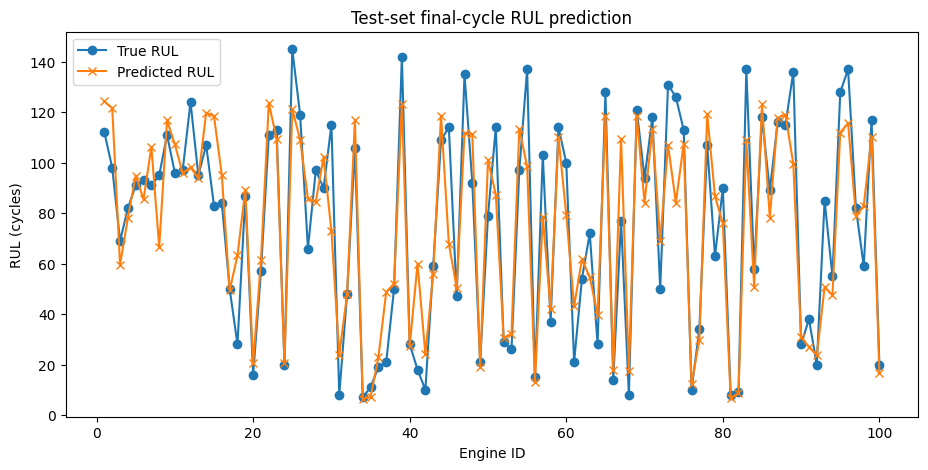

In [26]:
# 14. Test prediction plot
plt.figure(figsize=(11, 5))
plt.plot(test_last["unit"], test_last["true_RUL"], marker="o", label="True RUL")
plt.plot(test_last["unit"], test_last["predicted_RUL"], marker="x", label="Predicted RUL")
plt.xlabel("Engine ID")
plt.ylabel("RUL (cycles)")
plt.title("Test-set final-cycle RUL prediction")
plt.legend()
plt.show()


In [27]:
# 15. Maintenance recommendation
def maintenance_status(rul):
    if rul <= 15:
        return "CRITICAL"
    elif rul <= 30:
        return "WARNING"
    return "NORMAL"

test_last["maintenance_status"] = test_last["predicted_RUL"].apply(maintenance_status)

display(
    test_last[["unit", "predicted_RUL", "maintenance_status"]]
    .sort_values("predicted_RUL")
    .head(20)
)


,unit,predicted_RUL,maintenance_status
4267,34,6.255455,CRITICAL
10600,81,6.833262,CRITICAL
4465,35,7.165071,CRITICAL
10762,82,8.604096,CRITICAL
9919,76,12.325993,CRITICAL
7205,56,13.133267,CRITICAL
13095,100,16.726245,WARNING
8972,68,17.505115,WARNING
8714,66,17.743209,WARNING
6264,49,19.014775,WARNING


In [28]:
# 16. Save artifacts
os.makedirs("/content/models", exist_ok=True)

joblib.dump(rul_model, "/content/models/rul_random_forest.joblib")
joblib.dump(clf, "/content/models/failure_risk_random_forest.joblib")
joblib.dump(iso, "/content/models/isolation_forest.joblib")
joblib.dump(scaler, "/content/models/sensor_scaler.joblib")
joblib.dump(
    {"feature_cols": feature_cols, "sensor_cols": usable_sensors, "rul_cap": RUL_CAP},
    "/content/models/project_metadata.joblib"
)

test_last.to_csv("/content/test_rul_predictions.csv", index=False)

print("Models and prediction file saved in /content/models/")


Models and prediction file saved in /content/models/


# NASA C-MAPSS Predictive Maintenance Dashboard


### Engine Health Summary

- **Total Predictions:** 4070
- **Average Predicted RUL:** 87.52 cycles
- **Minimum Predicted RUL:** 1.62 cycles
- **Normal:** 2854
- **Warning:** 672
- **Critical:** 544

### Model Performance

- **MAE:** 10.81 cycles
- **RMSE:** 15.93 cycles
- **R² Score:** 0.854


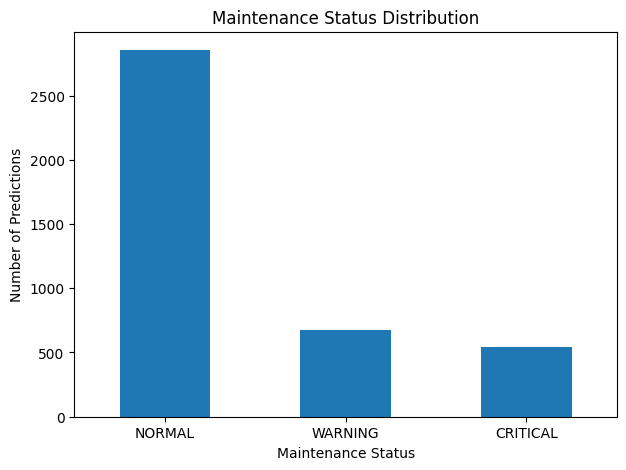

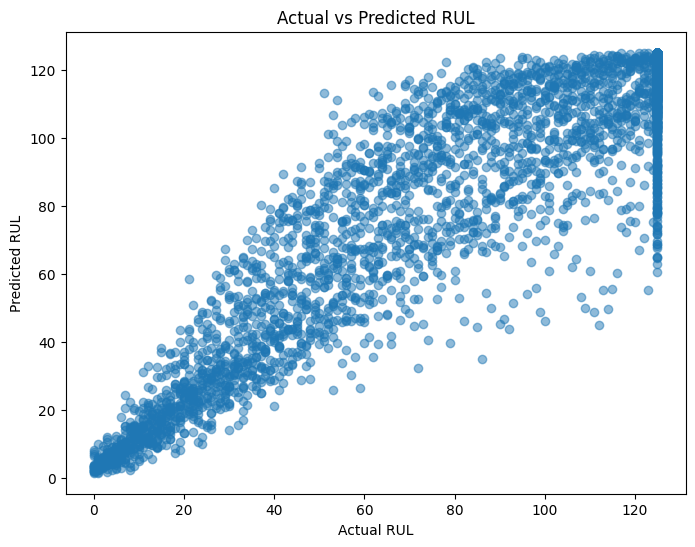

### Predictions Requiring Attention

,Actual_RUL,Predicted_RUL,Maintenance_Status
0,1,1.617716,CRITICAL
1,0,1.681187,CRITICAL
2,0,1.910784,CRITICAL
3,3,1.931403,CRITICAL
4,1,1.937915,CRITICAL
5,0,2.089260,CRITICAL
6,0,2.150091,CRITICAL
7,0,2.260203,CRITICAL
8,1,2.349289,CRITICAL
9,0,2.419563,CRITICAL


Dashboard generated successfully!


In [29]:
# 17. Predictive Maintenance Dashboard

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Create dashboard data from validation predictions
dashboard = pd.DataFrame({
    "Actual_RUL": np.asarray(y_val).ravel(),
    "Predicted_RUL": np.asarray(val_pred).ravel()
})

# Maintenance status
def get_status(rul):
    if rul <= 30:
        return "CRITICAL"
    elif rul <= 70:
        return "WARNING"
    else:
        return "NORMAL"

dashboard["Maintenance_Status"] = dashboard["Predicted_RUL"].apply(get_status)

# Summary
total_samples = len(dashboard)
critical = (dashboard["Maintenance_Status"] == "CRITICAL").sum()
warning = (dashboard["Maintenance_Status"] == "WARNING").sum()
normal = (dashboard["Maintenance_Status"] == "NORMAL").sum()

avg_rul = dashboard["Predicted_RUL"].mean()
min_rul = dashboard["Predicted_RUL"].min()

# Dashboard heading
display(Markdown("# NASA C-MAPSS Predictive Maintenance Dashboard"))

display(Markdown(f"""
### Engine Health Summary

- **Total Predictions:** {total_samples}
- **Average Predicted RUL:** {avg_rul:.2f} cycles
- **Minimum Predicted RUL:** {min_rul:.2f} cycles
- **Normal:** {normal}
- **Warning:** {warning}
- **Critical:** {critical}

### Model Performance

- **MAE:** {mae:.2f} cycles
- **RMSE:** {rmse:.2f} cycles
- **R² Score:** {r2:.3f}
"""))

# Maintenance status chart
status_counts = dashboard["Maintenance_Status"].value_counts()

plt.figure(figsize=(7,5))
status_counts.plot(kind="bar")
plt.title("Maintenance Status Distribution")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=0)
plt.show()

# Actual vs Predicted RUL
plt.figure(figsize=(8,6))
plt.scatter(dashboard["Actual_RUL"], dashboard["Predicted_RUL"], alpha=0.5)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

# Lowest predicted RUL
display(Markdown("### Predictions Requiring Attention"))

priority = dashboard.sort_values("Predicted_RUL").head(10)

display(priority.reset_index(drop=True))

print("Dashboard generated successfully!")